In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df_raw = pd.read_csv('../data/raw/allpaDB_layer_HARMONIZED_v1.csv')

print(f"Dimensiones iniciales del dataset: {df_raw.shape[0]} filas, {df_raw.shape[1]} columnas")
print("\nPrimeras 5 filas:")
df_raw.head()

Dimensiones iniciales del dataset: 24341 filas, 45 columnas

Primeras 5 filas:


,ID,font_type,doc_code,profile_code_0,profile_code,layer_name,upper_depth,lower_depth,TCEQ,CECPH7,...,MSTCOL,DRYCOL,MOTT,MOTCOL,MOTDEN,STRT,STRG,STRS,MMD,MMS
0,1,HD,HD_001,Angostura,Angostura,C1,0.0,10.0,0.85,2.24,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,HD,HD_001,Angostura,Angostura,C2,10.0,40.0,1.05,1.36,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,HD,HD_001,Angostura,Angostura,C3,40.0,55.0,0.66,2.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,HD,HD_001,Angostura,Angostura,C4,55.0,90.0,0.76,1.84,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,HD,HD_001,Angostura,Angostura,C5,90.0,200.0,0.19,7.76,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 24341 entries, 0 to 24340
Data columns (total 45 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              24341 non-null  int64  
 1   font_type       24341 non-null  str    
 2   doc_code        24341 non-null  str    
 3   profile_code_0  24341 non-null  str    
 4   profile_code    24341 non-null  str    
 5   layer_name      20701 non-null  str    
 6   upper_depth     23304 non-null  float64
 7   lower_depth     23303 non-null  float64
 8   TCEQ            21190 non-null  float64
 9   CECPH7          11916 non-null  float64
 10  ECEC            17355 non-null  float64
 11  ELCOSP          15074 non-null  float64
 12  ORGC            21609 non-null  float64
 13  PHAQ            22537 non-null  float64
 14  PHKC            535 non-null    float64
 15  PHNF            165 non-null    float64
 16  PHETOL          13698 non-null  float64
 17  NITKJD          13628 non-null  float64
 1

In [45]:
target = 'ORGC' # Columna objetivo: Carbono Orgánico en Suelo (SOC)
features = ['upper_depth', 'lower_depth', 'PHAQ', 'SAND', 'SILT', 'CLAY', 'TCEQ', 'ELCOSP', 'ECEC']

df_model = df_raw[features + [target]].copy()
df_model.head()

,upper_depth,lower_depth,PHAQ,SAND,SILT,CLAY,TCEQ,ELCOSP,ECEC,ORGC
0,0.0,10.0,8.2,90.0,8.0,2.0,0.85,1.032625,2.24,0.12
1,10.0,40.0,8.5,96.0,4.0,0.0,1.05,0.768510,1.36,0.12
2,40.0,55.0,8.5,94.0,6.0,0.0,0.66,1.351237,2.00,0.12
3,55.0,90.0,8.4,96.0,4.0,0.0,0.76,1.644262,1.84,0.08
4,90.0,200.0,8.0,40.0,54.0,6.0,0.19,3.087263,7.76,0.52


In [49]:
# Mostrando columnas con valores faltantes:
missing = pd.DataFrame({
    'missing': df_model.isna().sum(),
    'percentage(%)': df_model.isna().mean() * 100
})

missing.sort_values('percentage(%)', ascending=False)

,missing,percentage(%)
ELCOSP,9267,38.071566
ECEC,6986,28.700546
SILT,3463,14.227024
CLAY,3409,14.005176
SAND,3365,13.824411
TCEQ,3151,12.945236
ORGC,2732,11.223861
PHAQ,1804,7.411364
lower_depth,1038,4.264410
upper_depth,1037,4.260302


In [52]:
df_model.describe().T

,count,mean,std,min,25%,50%,75%,max
upper_depth,23304.0,30.541023,33.498706,0.00,0.0000,20.00,50.000000,247.000000
lower_depth,23303.0,68.385272,53.641339,2.00,25.0000,50.00,100.000000,300.000000
PHAQ,22537.0,6.570236,1.508146,0.08,5.1000,7.00,7.870000,10.600000
SAND,20976.0,50.626398,23.439781,0.00,32.0000,49.00,68.000000,100.000000
SILT,20878.0,27.784204,14.852601,0.00,18.0000,27.00,36.000000,442.000000
CLAY,20932.0,21.789587,16.309666,0.00,8.0000,19.60,32.000000,100.000000
TCEQ,21190.0,1.893822,5.529387,0.00,0.0000,0.00,0.900000,90.440000
ELCOSP,15074.0,14.420748,45.506882,0.00,0.3566,1.30,5.789559,980.620000
ECEC,17355.0,12.072326,59.144495,0.00,2.8000,8.36,14.860000,2476.420000
ORGC,21609.0,2.057364,6.281293,0.00,0.2800,0.69,1.531323,249.419954


En base a este resultado, se observa que ORGC (nuestro Target), tiene una distribución extraña, teniendo el 75% de la data en 1.53 y el máximo en 249, además que es data en porcentaje, por lo tanto, será totalmente necesario revisar su distribución.

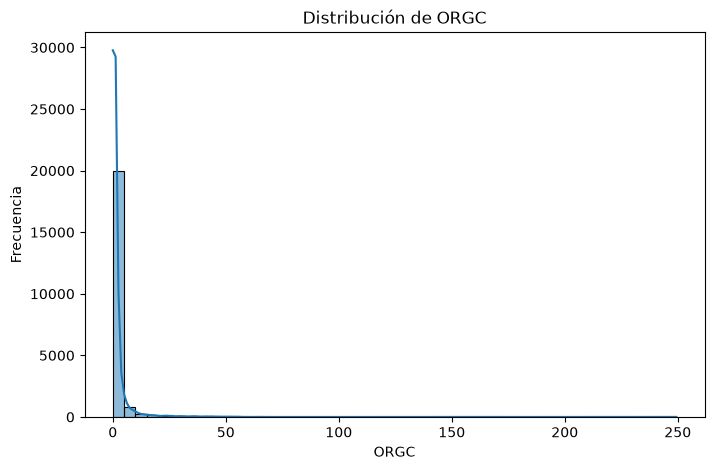

In [53]:
plt.figure(figsize=(8, 5))

sns.histplot(df_model['ORGC'].dropna(), bins=50, kde=True)

plt.title('Distribución de ORGC')
plt.xlabel('ORGC')
plt.ylabel('Frecuencia')
plt.show()

**Analizando la correlacion**

In [55]:
# Análisis de correlación entre características y la variable objetivo
correlation_matrix = df_model.corr()
correlation_with_target = correlation_matrix[target].sort_values(ascending=False)
correlation_with_target

ORGC           1.000000
SILT           0.115637
CLAY           0.053516
ECEC           0.025986
TCEQ          -0.040094
ELCOSP        -0.044596
SAND          -0.111543
upper_depth   -0.135710
lower_depth   -0.172120
PHAQ          -0.199180
Name: ORGC, dtype: float64

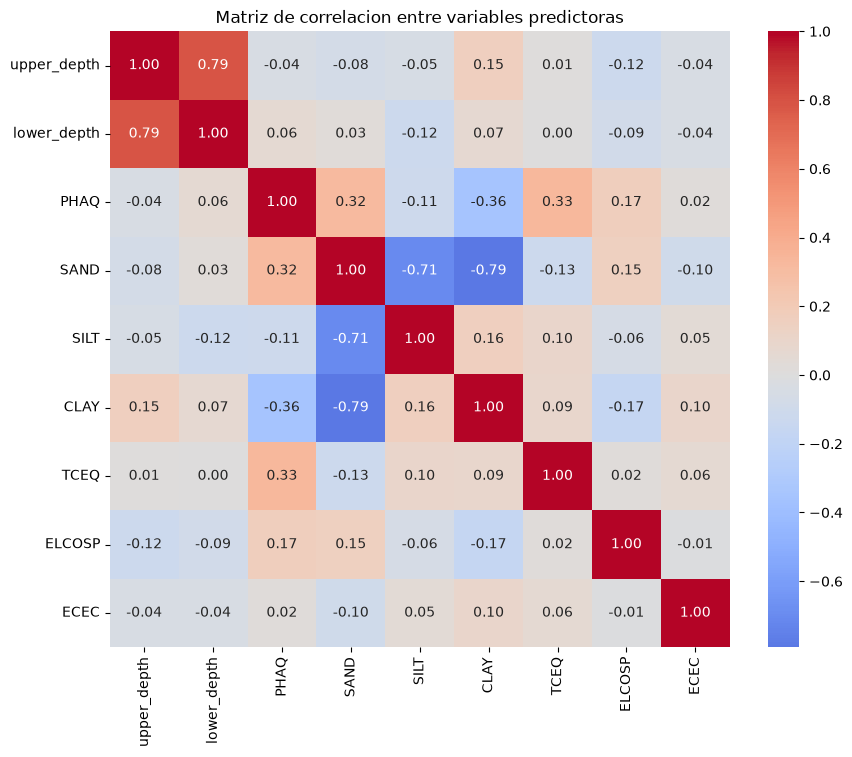

In [58]:
corr_features = df_model[features].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(corr_features, annot=True, fmt='.2f', cmap='coolwarm', center=0)

plt.title('Matriz de correlacion entre variables predictoras')
plt.show()

**Análisis de consistencia de datos**

In [68]:
# Variables de textura del suelo: SAND, SILT, CLAY
texture = df_model[['SAND', 'SILT', 'CLAY']].dropna().copy()

# Como la suma de SAND, SILT y CLAY debería ser 100, podemos verificar si hay inconsistencias en los datos.
texture['texture_sum'] = (
    texture['SAND'] +
    texture['SILT'] +
    texture['CLAY']
)

texture['texture_sum'].describe()

count    20848.000000
mean       100.039351
std          3.833281
min         20.000000
25%        100.000000
50%        100.000000
75%        100.000000
max        500.000000
Name: texture_sum, dtype: float64

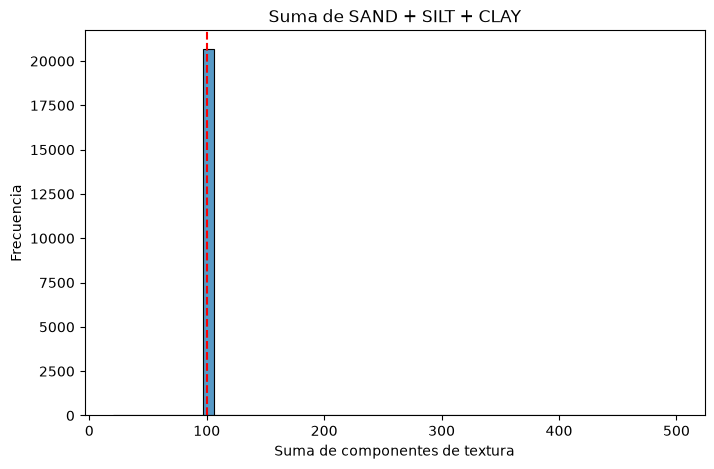

In [69]:
plt.figure(figsize=(8, 5))

sns.histplot(
    texture['texture_sum'],
    bins=50
)

plt.axvline(100, color='red', linestyle='--')

plt.title('Suma de SAND + SILT + CLAY')
plt.xlabel('Suma de componentes de textura')
plt.ylabel('Frecuencia')

plt.show()

In [61]:
# Verificación de la consistencia de las profundidades:
depth_check = df_model[
    ['upper_depth', 'lower_depth']
].dropna().copy()

depth_check['depth_difference'] = (
    depth_check['lower_depth'] -
    depth_check['upper_depth']
)

(depth_check['depth_difference'] <= 0).sum()

np.int64(0)

**Distribución de valores atípicos (outliers) en las características:**

In [63]:
numeric_cols = features + [target]
outlier_summary = []

for col in numeric_cols:
    x = df_model[col].dropna()

    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    n_outliers = ((x < lower) | (x > upper)).sum()

    outlier_summary.append({
        'variable': col,
        'Q1': q1,
        'Q3': q3,
        'lower_bound': lower,
        'upper_bound': upper,
        'outliers': n_outliers,
        'percentage': n_outliers / len(x) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary.sort_values('percentage',ascending=False)

,variable,Q1,Q3,lower_bound,upper_bound,outliers,percentage
6,TCEQ,0.0000,0.900000,-1.350000,2.250000,3793,17.899953
7,ELCOSP,0.3566,5.789559,-7.792838,13.938997,2445,16.219981
9,ORGC,0.2800,1.531323,-1.596984,3.408306,2398,11.097228
8,ECEC,2.8000,14.860000,-15.290000,32.950000,542,3.123019
4,SILT,18.0000,36.000000,-9.000000,63.000000,326,1.561452
0,upper_depth,0.0000,50.000000,-75.000000,125.000000,266,1.141435
5,CLAY,8.0000,32.000000,-28.000000,68.000000,174,0.831263
2,PHAQ,5.1000,7.870000,0.945000,12.025000,24,0.106492
1,lower_depth,25.0000,100.000000,-87.500000,212.500000,18,0.077243
3,SAND,32.0000,68.000000,-22.000000,122.000000,0,0.000000


**Análisis de distribución de target y features**

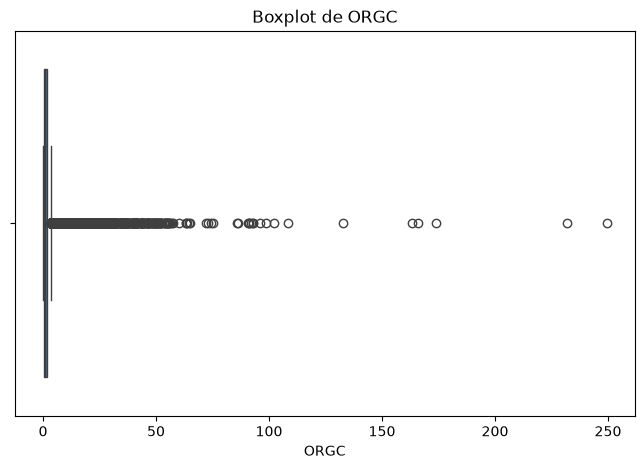

In [64]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x=df_model['ORGC']
)

plt.title('Boxplot de ORGC')
plt.xlabel('ORGC')

plt.show()

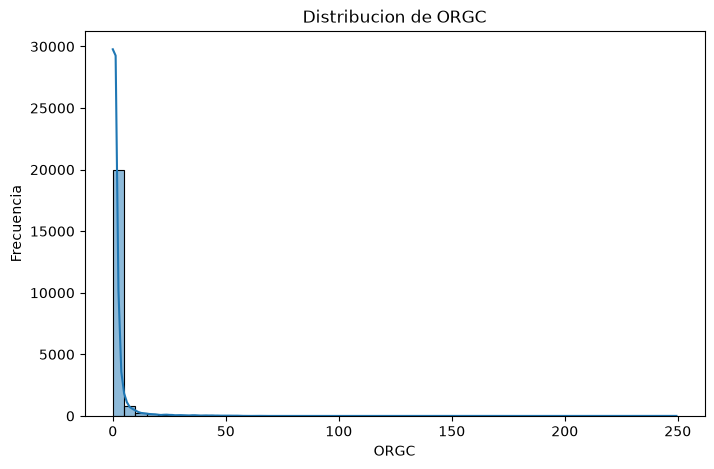

In [65]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df_model['ORGC'].dropna(),
    bins=50,
    kde=True
)

plt.title('Distribucion de ORGC')
plt.xlabel('ORGC')
plt.ylabel('Frecuencia')

plt.show()

In [71]:
from pathlib import Path
import sys

sys.path.append(str(Path.cwd().parent / 'src'))

from preprocessing import (
    prepare_data,
    create_preprocessor_scaled,
    create_preprocessor_unscaled
)

X, y = prepare_data(df_raw)

print('X:', X.shape)
print('y:', y.shape)

X: (21609, 9)
y: (21609,)


In [ ]:
preprocessor = create_preprocessor_scaled()
X_processed = preprocessor.fit_transform(X)

print(X_processed.shape)

(21609, 9)


In [73]:
print('NaN:', np.isnan(X_processed).sum())

NaN: 0
